<a href="https://colab.research.google.com/github/FOFM030711/SIMULACION-II/blob/main/PROYECT_SIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto: Ajuste de parámetros del modelo SIR**

1. Graficar datos.
2. Programar la solución númerica del modelo SIR.
3. Plantear un ajuste por mínimos cuadrados, $χ^2$, $(a,b)$ (chi cuadrada)
4. Usar el método MCMC (Metropolis Hastings) para optimizar $χ^2$.
5. Replantear con $pyMC$ en el enfoque bayesiano.

**Modelo SIR**


El modelo **SIR** consiste en tres Ecuacuiones Diferenciales Ordinarias No Lineales, no tiene una solucion analiticamente explicita. Es basicamente un modelo de enfermedades infecciosas.
Consiste en:
$$\frac{dS}{dt}=-aSI$$
$$\frac{dI}{dt}=aSI-bI$$
$$\frac{dR}{dt}=bI$$
donde
* $S=S(t)$ es susceptible
* $I(t)$ es infectado
* $R(t)$ es recuperado
* $a$ es la tasa de transmisión
* $b$ es la tasa de recuperación promedio

En cualquier momento, la población total es  $N = S + I + R$ y permanece constante como $N = S+ I+ R = 0$, donde el punto superior
indica la derivada con respecto al tiempo $t$.

Inicialmente, $S(t)$ es aproximadamente igual a $N$ e $I(t)$ es muy pequeño. En un brote, típicamente $I(t)$ aumenta cada día hasta alcanzar un máximo y luego tiende a disminuir lentamente.
Resulta particularmente útil determinar el número reproductivo, definido como $R_0 = \frac{a}{b}$ ya que el análisis del sistema dinámico indica que:
$$\frac{I_{max}}{N}=1-\frac{1}{R_0}(1+logR_0)$$

Por tanto, determinar los parámetros del modelo permite establecer el número máximo de infectados, una cifra que puede resultar útil para desarrollar medidas de salud pública. Incluso una vez ocurrido el evento, conocer los parámetros *a* y *b* del modelo es de interés, ya que sirven para caracterizar la enfermedad. Este es precisamente el problema que nos interesa resolver: determinar el par de parámetros $(a, b)$ del modelo $SIR$ a partir de un conjunto de datos.


**PROBLEMA:**
Marinov, plantea este problema para un conjunto de datos a un brote de gripe en un internado. Estos datos se citaron por primera vez en  y se reproducen en la tabla siguiente; la solución obtenida por Murray. Según, los valores de los parámetros $a$ y $b$ son los siguientes: $a ≈ 0.00218$ y $b ≈ 0.4485$.



In [3]:
# Importamos las librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


In [4]:
# Datos de Murray


**Tabla de datos de Influenza en una escuela**

$
\boxed{
\begin{array}{lc}
\text{t} & 0 &  1& 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 &  12 & 13 & 14   \\
\hline
\text{$I(t)$} & 1& 3& 6& 25& 73& 222&294 &258 &237 &191 & 125 &69 & 27 & 11& 4\\
\end{array}
}
$

In [5]:
# 1. DATOS EXPERIMENTALES (informaciòn de la tabla anterior)


# Tiempo (días)
t_datos = np.array([
    0, 1, 2, 3, 4, 5, 6, 7,
    8, 9, 10, 11, 12, 13, 14
])

# Número de personas infectadas observado
I_datos = np.array([
    1, 3, 6, 25, 73, 222, 294, 258,
    237, 191, 125, 69, 27, 11, 4
])



In [6]:


# 2. PARÁMETROS DEL MODELO

# Parámetro de transmisión
a = 0.00218

# Parámetro de recuperación/remoción
b = 0.4485


In [7]:

# 3. CONDICIONES INICIALES

# Población total
N = 763

# Susceptibles inicialmente
S0 = 762

# Infectados inicialmente
I0 = 1

# Recuperados inicialmente
R0 = 0

# Vector de condiciones iniciales
condiciones_iniciales = [S0, I0, R0]

**Definimos el modelo SIR**
$$\frac{dS}{dt}=-aSI$$
$$\frac{dI}{dt}=aSI-bI$$
$$\frac{dR}{dt}=bI$$
donde
* $S=S(t)$ es susceptible
* $I(t)$ es infectado
* $R(t)$ es recuperado
* $a$ es la tasa de transmisión
* $b$ es la tasa de recuperación promedio

In [8]:


def modelo_SIR(t, y):

    # Extraemos las variables
    S, I, R = y

    # Ecuación de susceptibles
    dSdt = -a * S * I

    # Ecuación de infectados
    dIdt = a * S * I - b * I

    # Ecuación de recuperados
    dRdt = b * I

    # Regresamos las derivadas
    return [dSdt, dIdt, dRdt]


In [9]:


# 5. RESOLVEMOS EL SISTEMA DE ECUACIONES DIFERENCIALES

# Intervalo de tiempo
t_inicio = 0
t_final = 14

# Creamos muchos puntos para obtener una curva suave
t = np.linspace(t_inicio, t_final, 1000)

# Resolvemos numéricamente el sistema
solucion = solve_ivp(
    modelo_SIR,
    [t_inicio, t_final],
    condiciones_iniciales,
    t_eval=t
)


In [10]:

# 6. EXTRAEMOS LAS SOLUCIONES

S = solucion.y[0]
I = solucion.y[1]
R = solucion.y[2]


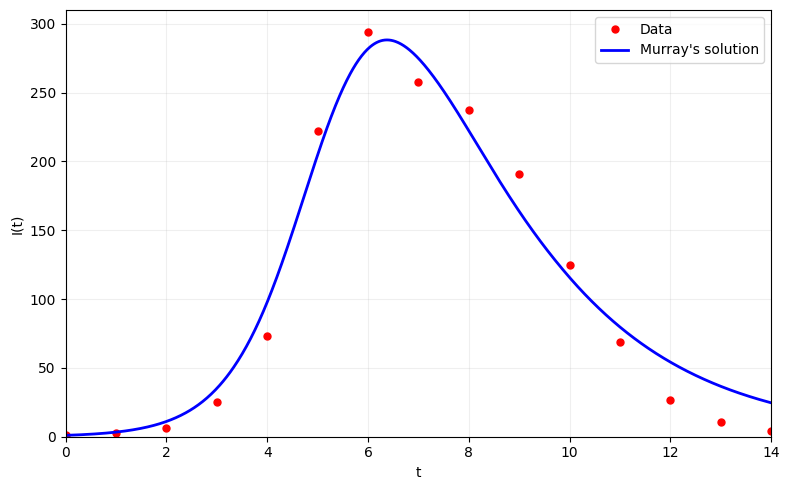

In [11]:

# 7. GRAFICAMOS LOS DATOS Y LA SOLUCIÓN DE MURRAY

plt.figure(figsize=(8, 5))

# Puntos de los datos
plt.plot(
    t_datos,
    I_datos,
    'o',
    color='red',
    markersize=5,
    label='Data'
)

# Curva de Murray
plt.plot(
    t,
    I,
    color='blue',
    linewidth=2,
    label="Murray's solution"
)

plt.xlabel('t')
plt.ylabel('I(t)')

plt.xlim(0, 14)
plt.ylim(0, 310)

plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


 **La solución numérica obtenida a partir de los parámetros determinados por Murray**


Utilizamos este conjunto de datos como prueba preliminar del método. Más adelante, intentaremos aplicarlo con más datos y/o condiciones más complejas. Como puede observarse, los datos nos proporcionan las condiciones iniciales, $I(0) = 1$; por tanto, al determinar los parámetros del sistema de ecuaciones, el modelo quedará completamente definido.

# Estimación de párametros del modelo SIR usando un AG

In [14]:
# ============================================================
# INSTALACIÓN DE DEAP
# ============================================================

!pip install deap

In [35]:
# Librerías para resolver numéricamente el sistema de ecuaciones
from scipy.integrate import odeint
from scipy.interpolate import interp1d

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para el algoritmo genético
from deap import base, creator, tools

import random

# Módulo para implementar elitismo (assuming elitism.py is created)
import elitism

ModuleNotFoundError: No module named 'elitism'

### Optimización con el algoritmo genético

In [20]:
# problem constants:
DIMENSIONS = 2  # number of dimensions
BOUND_LOW, BOUND_UP = 0.0, 1.0  # boundaries for all dimensions

In [21]:
# Genetic Algorithm constants:
POPULATION_SIZE = 100
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.45  # (try also 0.5) probability for mutating an individual
MAX_GENERATIONS = 500
HALL_OF_FAME_SIZE = 1
CROWDING_FACTOR = 1.0  # crowding factor for crossover and mutation

# set the random seed:
#RANDOM_SEED = 42
#random.seed(RANDOM_SEED)

In [22]:
toolbox = base.Toolbox()

In [23]:
# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

/usr/local/lib/python3.13/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [24]:
# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

/usr/local/lib/python3.13/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [25]:
# helper function for creating random real numbers uniformly distributed within a given range [low, up]
# it assumes that the range is the same for every dimension
def randomFloat(low, up):
    return [random.uniform(l, u) for l, u in zip([low] * DIMENSIONS, [up] * DIMENSIONS)]

In [26]:
# create an operator that randomly returns a float in the desired range and dimension:
toolbox.register("attrFloat", randomFloat, BOUND_LOW, BOUND_UP)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initIterate, creator.Individual, toolbox.attrFloat)

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)

In [27]:
# Sistema de ecuaciones del modelo SIR.
def deriv(Y, t, N, a, b):
    S, I, R = Y
    dSdt = -a * S * I
    dIdt = a * S * I - b * I
    dRdt = b * I
    return dSdt, dIdt, dRdt

In [28]:
# Esta funcion calcula la distancia Manhattan entre los datos numericos y los reales.

def manhattan(individual):
    x = individual[0]
    y = individual[1]

    N = 763

    I0, R0 = 1, 0
    S0 = N - I0 - R0
    t = np.linspace(0, 15, 15)

    y0 = S0, I0, R0

    ret = odeint(deriv, y0, t, args=(N, x, y))
    S, I, R = ret.T


#    delta = np.absolute(ret.T[1] - datos_school)
#    f = np.sum(delta)

    delta = (np.absolute(ret.T[1] - datos_school)**2)/ret.T[1]
    f = np.sum(delta)

    return f,

In [29]:
datos_school = [1, 3, 6, 25, 73, 222, 294, 258, 237, 191, 125, 69, 27, 11, 4 ]

In [30]:
toolbox.register("evaluate", manhattan)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR,
                 indpb=1.0/DIMENSIONS)

In [38]:
%%writefile elitism.py

import random
from deap import tools


def eaSimpleWithElitism(population, toolbox, cxpb, mutpb, ngen,
                        stats=None, halloffame=None, verbose=True):

    logbook = tools.Logbook()
    logbook.header = ["gen", "nevals"]

    if stats is not None:
        logbook.header += stats.fields

    # Evaluar individuos de la población inicial
    invalid_ind = [
        ind for ind in population
        if not ind.fitness.valid
    ]

    fitnesses = map(toolbox.evaluate, invalid_ind)

    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Actualizar Hall of Fame
    if halloffame is not None:
        halloffame.update(population)

    # Registrar estadísticas iniciales
    record = stats.compile(population) if stats else {}

    logbook.record(
        gen=0,
        nevals=len(invalid_ind),
        **record
    )

    if verbose:
        print(logbook.stream)

    # =========================================================
    # CICLO PRINCIPAL DEL ALGORITMO GENÉTICO
    # =========================================================

    for gen in range(1, ngen + 1):

        # -----------------------------------------------------
        # ELITISMO
        # -----------------------------------------------------
        # Guardamos el mejor individuo de la generación anterior

        elite = tools.selBest(
            population,
            1
        )[0]

        elite = toolbox.clone(elite)

        # -----------------------------------------------------
        # SELECCIÓN
        # -----------------------------------------------------

        offspring = toolbox.select(
            population,
            len(population) - 1
        )

        offspring = list(
            map(toolbox.clone, offspring)
        )

        # -----------------------------------------------------
        # CRUZAMIENTO
        # -----------------------------------------------------

        for child1, child2 in zip(
            offspring[::2],
            offspring[1::2]
        ):

            if random.random() < cxpb:

                toolbox.mate(
                    child1,
                    child2
                )

                del child1.fitness.values
                del child2.fitness.values

        # -----------------------------------------------------
        # MUTACIÓN
        # -----------------------------------------------------

        for mutant in offspring:

            if random.random() < mutpb:

                toolbox.mutate(mutant)

                del mutant.fitness.values

        # -----------------------------------------------------
        # EVALUACIÓN
        # -----------------------------------------------------

        invalid_ind = [
            ind for ind in offspring
            if not ind.fitness.valid
        ]

        fitnesses = map(
            toolbox.evaluate,
            invalid_ind
        )

        for ind, fit in zip(
            invalid_ind,
            fitnesses
        ):

            ind.fitness.values = fit

        # -----------------------------------------------------
        # ACTUALIZAR HALL OF FAME
        # -----------------------------------------------------

        if halloffame is not None:
            halloffame.update(offspring)

        # -----------------------------------------------------
        # NUEVA POBLACIÓN
        # -----------------------------------------------------
        # El mejor individuo pasa directamente a la siguiente
        # generación sin cruzamiento ni mutación.

        population[:] = [elite] + offspring

        # -----------------------------------------------------
        # ESTADÍSTICAS
        # -----------------------------------------------------

        record = stats.compile(population) if stats else {}

        logbook.record(
            gen=gen,
            nevals=len(invalid_ind),
            **record
        )

        if verbose:
            print(logbook.stream)

    return population, logbook

Writing elitism.py


In [39]:
import elitism

print("Módulo elitism cargado correctamente.")

Módulo elitism cargado correctamente.


gen	nevals	min    	avg   
0  	100   	1943.28	223214
1  	96    	1941.15	80444.7
2  	86    	1941.15	23989.7
3  	88    	1941.15	12079.4
4  	93    	1941.01	30582.6
5  	92    	1941.01	29659.1
6  	97    	1941.01	54737.2
7  	90    	1941.01	10659.4
8  	91    	1941.01	24800.6
9  	93    	1941.01	34653.1
10 	97    	1941.01	74317  
11 	99    	1941.01	51068.5
12 	93    	1941.01	56422.2
13 	93    	1941.01	45405.7
14 	95    	1941.01	8513.49
15 	91    	1158.86	12948.9
16 	94    	1158.86	18487.2
17 	90    	1158.86	48992.4
18 	91    	1158.86	18130.9
19 	97    	1158.86	34536.8
20 	92    	980.044	10218.1
21 	88    	980.044	48481.7
22 	87    	980.044	28196  
23 	92    	980.044	45647  
24 	92    	654.381	44298.8
25 	94    	654.381	45726.2
26 	93    	654.381	42272.8
27 	96    	654.381	6314.93
28 	91    	654.381	10606.5
29 	94    	654.381	13735.2
30 	93    	654.381	11868.2
31 	95    	654.381	4725.14
32 	92    	654.381	42967.4
33 	93    	654.381	78847.8
34 	93    	654.381	3164.61
35 	99    	654.381	12976.6
36 

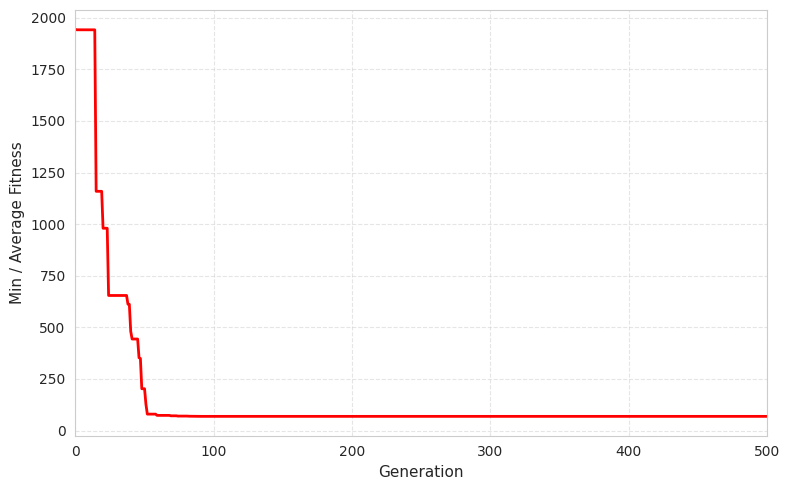

In [41]:

# Genetic Algorithm flow:

def main():


    # CREAR POBLACIÓN INICIAL


    population = toolbox.populationCreator(
        n=POPULATION_SIZE
    )


    # ESTADÍSTICAS


    stats = tools.Statistics(
        lambda ind: ind.fitness.values
    )

    stats.register(
        "min",
        np.min
    )

    stats.register(
        "avg",
        np.mean
    )


    # HALL OF FAME


    hof = tools.HallOfFame(
        HALL_OF_FAME_SIZE
    )


    # ALGORITMO GENÉTICO CON ELITISMO


    population, logbook = elitism.eaSimpleWithElitism(
        population,
        toolbox,
        cxpb=P_CROSSOVER,
        mutpb=P_MUTATION,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=True
    )


    # MEJOR SOLUCIÓN ENCONTRADA


    best = hof.items[0]

    print("\n-- Best Individual = ", best)

    print(
        "-- Best Fitness = ",
        best.fitness.values[0]
    )

    # EXTRAER ESTADÍSTICAS


    minFitnessValues, meanFitnessValues = logbook.select(
        "min",
        "avg"
    )



    # GRÁFICA

    sns.set_style("whitegrid")

    plt.figure(figsize=(8, 5))

    plt.plot(
        minFitnessValues,
        color='red',
        linewidth=2
    )

    plt.xlabel(
        'Generation',
        fontsize=11
    )

    plt.ylabel(
        'Min / Average Fitness',
        fontsize=11
    )

    plt.xlim(
        0,
        MAX_GENERATIONS
    )

    plt.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

    plt.tight_layout()

    plt.savefig(
        'GA_Evolution_1.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()



# EJECUTAR

if __name__ == "__main__":
    main()

In [44]:
def funcion_objetivo(x_0, x_1):

    N = 763
    I0, R0 = 1, 0
    S0 = N - I0 - R0
    t = np.linspace(0, 15, 15)

    y0 = S0, I0, R0


    def deriv(y, t, N, beta, gamma):
        S, I, R = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return dSdt, dIdt, dRdt

    ret = odeint(deriv, y0, t, args=(N, x_0, x_1))
    S, I, R = ret.T


#    datos = ret.T[1]
#    print(ret.T[1])

    fig = plt.figure(facecolor='w')
    ax = fig.add_subplot(111, axisbelow='line')
    ax.plot(datos_school, 'ro', alpha=0.5, lw=2, label='Data')
#    ax.plot(t, ret.T[1], 'b', alpha=0.5, lw=2, label='Best fitness')
    f2 = interp1d(t, ret.T[1], kind='cubic')
    t = np.linspace(0, 15, num=101)
    ax.plot(t, f2(t), 'b', alpha=0.5, lw=2, label='Best fit')
    ax.set_xlabel('t', fontsize=15)
    ax.set_ylabel('I(t)', fontsize=15)
    #ax.set_title("GA's approximation", fontsize=15)
    ax.legend()
    plt.grid(visible = False)
    fig.savefig('best_fit.png')
    plt.show()

    delta = np.absolute(ret.T[1] - datos_school)
    manhattan = np.sum(delta)
    f = manhattan

    return(f)

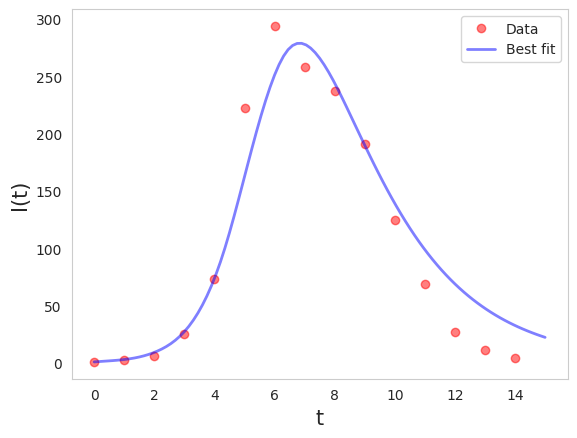

np.float64(233.91513917335863)

In [45]:
#funcion_objetivo(0.00218, 0.4436)
funcion_objetivo(0.002047488430022274, 0.4355147691971053)